# Heart Disease Prediction Project

Goal: predict whether a patient has heart disease.

We will follow this workflow:

1. Load the dataset  
2. Understand rows, columns, and target  
3. Clean missing values  
4. Split data into features `X` and target `y`  
5. Split into training and testing data  
6. Train a Logistic Regression model  
7. Evaluate the model


## Step 1 — Import libraries

Libraries are reusable tools:

- `pandas`: used for tables/dataframes
- `numpy`: used for numerical operations and missing values
- `matplotlib`: used for plotting charts


In [42]:
# Import pandas and give it the short name pd.
# We use pandas to load and work with tabular data.
import pandas as pd

# Import numpy and give it the short name np.
# We use numpy mainly for NaN, which represents missing values.
import numpy as np

# Import matplotlib for simple visualizations.
import matplotlib.pyplot as plt


## Step 2 — Define column names

The raw file does not contain column headers, so we manually provide the 14 column names from the dataset documentation.

The last column, `target`, is what we want to predict.


In [45]:
# These are the 14 columns used in the common Cleveland heart disease dataset.
columns = [
    "age",       # patient's age
    "sex",       # sex: 1 = male, 0 = female
    "cp",        # chest pain type
    "trestbps",  # resting blood pressure
    "chol",      # cholesterol level
    "fbs",       # fasting blood sugar > 120 mg/dl: 1 = true, 0 = false
    "restecg",   # resting ECG results
    "thalach",   # maximum heart rate achieved
    "exang",     # exercise-induced angina: 1 = yes, 0 = no
    "oldpeak",   # ST depression induced by exercise
    "slope",     # slope of peak exercise ST segment
    "ca",        # number of major vessels colored by fluoroscopy
    "thal",      # thalassemia test result
    "target"     # diagnosis: 0 = no disease, 1-4 = disease
]


## Step 3 — Load the dataset

Each row represents one patient.

Each column represents one feature/measurement about that patient.


In [48]:
# Read the data file into a pandas DataFrame.
# names=columns tells pandas to use our column names because the file has no header row.
df = pd.read_csv("processed.cleveland.data", names=columns)

# Show the first 5 rows so we can quickly verify the data loaded correctly.
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Step 4 — Basic checks

Before building a model, always inspect the dataset.

We check:

- shape: number of rows and columns
- data types: whether columns are numeric or text/object
- target distribution: how many healthy vs disease cases


In [51]:
# Show number of rows and columns.
# Example output: (303, 14) means 303 patients and 14 columns.
print("Dataset shape:", df.shape)

# Show column types and non-null counts.
# This helps us detect columns that are accidentally stored as text.
print("Dataset info:")
df.info()


Dataset shape: (303, 14)
Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    str    
 12  thal      303 non-null    str    
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), str(2)
memory usage: 33.3 KB


In [53]:
# Check the original target values before simplifying.
# In this dataset:
# 0 means no heart disease.
# 1, 2, 3, and 4 mean different levels/presence of heart disease.
print(df["target"].value_counts().sort_index())


target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## Step 5 — Convert the target into a simple binary label

For a beginner project, we convert the target into only two classes:

- `0` = no heart disease
- `1` = heart disease present

So original values `1`, `2`, `3`, and `4` all become `1`.


In [56]:
# Convert target into binary classification.
# If target is greater than 0, it becomes 1.
# If target is 0, it stays 0.
df["target"] = (df["target"] > 0).astype(int)

# Check the new class counts.
print(df["target"].value_counts())


target
0    164
1    139
Name: count, dtype: int64


## Step 6 — Clean missing values

This dataset uses `?` to represent missing values.

Machine learning models cannot understand `?`, so we replace it with `NaN`, which pandas understands as missing.


In [59]:
# Replace every question mark in the entire DataFrame with NaN.
# NaN means missing value.
df = df.replace("?", np.nan)

# Convert all columns to numeric values.
# This is needed because columns containing "?" may have been read as text/object.
df = df.apply(pd.to_numeric)

# Count missing values in each column.
print(df.isnull().sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


## Step 7 — Remove rows with missing values

Because this dataset has only a few missing rows, we use the simplest approach: remove those rows.

In larger projects, we might fill missing values instead, but dropping is fine here for learning.


In [62]:
# Remove rows that contain at least one missing value.
df = df.dropna()

# Verify that no missing values remain.
print("Total missing values after cleaning:", df.isnull().sum().sum())

# Check the final cleaned dataset shape.
print("Cleaned dataset shape:", df.shape)


Total missing values after cleaning: 0
Cleaned dataset shape: (297, 14)


## Step 8 — Separate features and target

Supervised learning uses:

- `X`: input features used for prediction
- `y`: target/output we want to predict

Here:

- `X` = patient measurements such as age, cholesterol, blood pressure
- `y` = heart disease label


In [65]:
# X contains all columns except the target column.
X = df.drop("target", axis=1)

# y contains only the target column.
y = df["target"]

# Check their shapes.
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (297, 13)
y shape: (297,)


## Step 9 — Train/test split

We split the data into two parts:

- training data: the model learns from this
- testing data: we use this to evaluate the model on unseen data

Here we use 80% training data and 20% testing data.


In [68]:
# Import train_test_split, which splits data into training and testing sets.
from sklearn.model_selection import train_test_split

# Split X and y into training and testing parts.
# test_size=0.2 means 20% of the data is used for testing.
# random_state=42 makes the split reproducible, so results stay the same each time.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print the shapes so we can understand how much data went into train/test.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (237, 13)
X_test shape: (60, 13)
y_train shape: (237,)
y_test shape: (60,)


## Step 10 — Train a Logistic Regression model

Logistic Regression is a simple and common baseline model for binary classification.

It is a good first model because it is easier to understand than many complex models.


In [71]:
# Import Logistic Regression model.
from sklearn.linear_model import LogisticRegression

# Create the model.
# max_iter=1000 gives the model enough chances to find a good solution.
model = LogisticRegression(max_iter=1000)

# Train the model using training data.
# X_train = input features
# y_train = correct answers/labels
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Step 11 — Make predictions

Now we use the trained model to predict heart disease on test data.

The model has not seen this test data during training.


In [73]:
# Predict target values for the test features.
y_pred = model.predict(X_test)

# Show the first few predictions.
print("First 10 predictions:", y_pred[:10])

# Show the first few actual answers for comparison.
print("First 10 actual values:", y_test.values[:10])


First 10 predictions: [0 0 0 1 0 0 0 1 1 0]
First 10 actual values: [0 1 0 1 0 0 0 0 1 0]


## Step 12 — Evaluate accuracy

Accuracy means:

> Out of all predictions, how many were correct?

Example: accuracy of `0.88` means about 88% correct.


In [76]:
# Import accuracy_score to measure model correctness.
from sklearn.metrics import accuracy_score

# Compare actual answers y_test with predicted answers y_pred.
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")


Accuracy: 0.8833333333333333
Accuracy percentage: 88.33 %


## Step 13 — Confusion matrix and classification report

Accuracy is useful, but for medical problems we also want to see the types of mistakes.

The confusion matrix shows:

- healthy predicted as healthy
- healthy predicted as disease
- disease predicted as healthy
- disease predicted as disease

The classification report gives precision, recall, and F1-score.


In [81]:
# Import evaluation tools.
from sklearn.metrics import confusion_matrix, classification_report

# Confusion matrix shows correct and incorrect predictions by class.
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Classification report shows precision, recall, f1-score, and support.
print("Classification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[32  4]
 [ 3 21]]
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        36
           1       0.84      0.88      0.86        24

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



## Step 14 — Visualize the confusion matrix

This gives the same information as the confusion matrix, but as a chart.


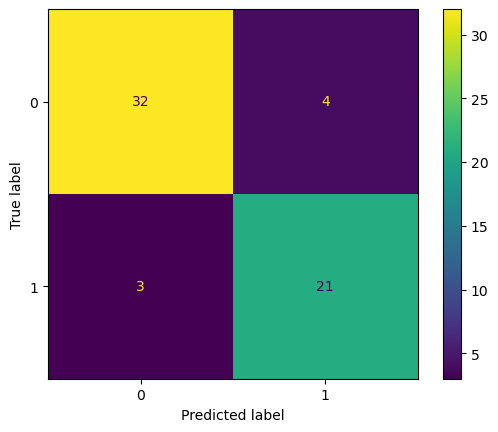

In [84]:
# Import display helper for confusion matrix visualization.
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix plot using the trained model and test data.
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

# Show the plot.
plt.show()


## Final Summary

You completed the core supervised ML workflow:

1. Loaded data  
2. Cleaned missing values  
3. Created features `X` and target `y`  
4. Split into train/test data  
5. Trained a Logistic Regression model  
6. Made predictions  
7. Evaluated model performance

This is a real beginner end-to-end machine learning project.
